In [ ]:
9!pip install transformers
!pip install sentencepiece
!pip install nltk
!pip install seaborn

**Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

**Download NLP Resources**

In [ ]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

**Dataset Uploading**

In [ ]:
df = pd.read_csv('/content/sample_data/stockerbot-export1.csv')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

To view Dataset

In [ ]:
df.head()

,id,text,timestamp,source,symbols,company_names,url,verified
0,1.0197E+18,VIDEO: “I was in my office. I was minding my o...,Wed Jul 18 21:33:26 +0000 2018,GoldmanSachs,GS,The Goldman Sachs,https://twitter.com/i/web/status/1019696670777...,TRUE
1,1.01971E+18,The price of lumber $LB_F is down 22% since hi...,Wed Jul 18 22:22:47 +0000 2018,StockTwits,M,Macy's,https://twitter.com/i/web/status/1019709091038...,TRUE
2,1.01971E+18,Who says the American Dream is dead? https://t...,Wed Jul 18 22:32:01 +0000 2018,TheStreet,AIG,American,https://buff.ly/2L3kmc4,TRUE
3,1.01972E+18,Barry Silbert is extremely optimistic on bitco...,Wed Jul 18 22:52:52 +0000 2018,MarketWatch,BTC,Bitcoin,https://twitter.com/i/web/status/1019716662587...,TRUE
4,1.01972E+18,How satellites avoid attacks and space junk wh...,Wed Jul 18 23:00:01 +0000 2018,Forbes,ORCL,Oracle,http://on.forbes.com/6013DqDDU,TRUE


Checking of Datastructure

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28440 entries, 0 to 28439
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id             28440 non-null  object
 1   text           28440 non-null  object
 2   timestamp      28438 non-null  object
 3   source         28437 non-null  object
 4   symbols        28437 non-null  object
 5   company_names  28435 non-null  object
 6   url            22049 non-null  object
 7   verified       28436 non-null  object
dtypes: object(8)
memory usage: 1.7+ MB


Checking of columns

In [ ]:
df.columns

Index(['id', 'text', 'timestamp', 'source', 'symbols', 'company_names', 'url',
       'verified'],
      dtype='object')

**STEP 6 — Check Missing Values ..**


 As missing texts causes most errors in NLP models



In [ ]:
df.isnull().sum()

,0
id,0
text,0
timestamp,2
source,3
symbols,3
company_names,5
url,6391
verified,4


In [ ]:
df = df[['text']]

In [ ]:
df.head()

,text
0,VIDEO: “I was in my office. I was minding my o...
1,The price of lumber $LB_F is down 22% since hi...
2,Who says the American Dream is dead? https://t...
3,Barry Silbert is extremely optimistic on bitco...
4,How satellites avoid attacks and space junk wh...


STEP 8 — Remove Missing Tweets

In [ ]:
df.dropna(inplace=True)

In [ ]:
print(df.shape)

(28440, 1)


STEP 9 — Create Copy of Original Text

In [ ]:
df['original_text'] = df['text']

STEP 10 — Text Cleaning Function

In [ ]:
def clean_text(text):

    text = str(text)

    # remove URLs
    text = re.sub(r"http\S+", "", text)

    # remove mentions
    text = re.sub(r"@\w+", "", text)

    # remove special characters
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # lowercase
    text = text.lower()

    # remove extra spaces
    text = text.strip()

    return text

STEP 11 — Apply Cleaning

In [ ]:
df['clean_text'] = df['text'].apply(clean_text)

In [ ]:
df[['text','clean_text']].head(10)

,text,clean_text
0,VIDEO: “I was in my office. I was minding my o...,video i was in my office i was minding my own ...
1,The price of lumber $LB_F is down 22% since hi...,the price of lumber lbf is down since hitting...
2,Who says the American Dream is dead? https://t...,who says the american dream is dead
3,Barry Silbert is extremely optimistic on bitco...,barry silbert is extremely optimistic on bitco...
4,How satellites avoid attacks and space junk wh...,how satellites avoid attacks and space junk wh...
5,.@RealMoney's David Butler's favorite FANG sto...,s david butlers favorite fang stock isnt realm...
6,Don’t miss my convo with one of my favorite th...,dont miss my convo with one of my favorite thi...
7,U.S. intelligence documents on Nelson Mandela ...,us intelligence documents on nelson mandela ma...
8,Senate wants emergency alerts to go out throug...,senate wants emergency alerts to go out throug...
9,Hedge fund manager Marc Larsy says bitcoin $40...,hedge fund manager marc larsy says bitcoin k i...


STEP 12 — Remove Stopwords

words like the, is, for, at, and

Create stopword function

In [ ]:
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):

    words = word_tokenize(text)

    filtered_words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(filtered_words)

Apply stopword removal

In [ ]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
df['processed_text'] = (
    df['clean_text']
    .apply(remove_stopwords)
)

STEP 13 — Check Final Processed Text

In [ ]:
df[
    ['original_text',
     'processed_text']
].head(10)

,original_text,processed_text
0,VIDEO: “I was in my office. I was minding my o...,video office minding business david solomon te...
1,The price of lumber $LB_F is down 22% since hi...,price lumber lbf since hitting ytd highs macys...
2,Who says the American Dream is dead? https://t...,says american dream dead
3,Barry Silbert is extremely optimistic on bitco...,barry silbert extremely optimistic bitcoin pre...
4,How satellites avoid attacks and space junk wh...,satellites avoid attacks space junk circling e...
5,.@RealMoney's David Butler's favorite FANG sto...,david butlers favorite fang stock isnt realmon...
6,Don’t miss my convo with one of my favorite th...,dont miss convo one favorite thinkers
7,U.S. intelligence documents on Nelson Mandela ...,us intelligence documents nelson mandela made ...
8,Senate wants emergency alerts to go out throug...,senate wants emergency alerts go netflix spoti...
9,Hedge fund manager Marc Larsy says bitcoin $40...,hedge fund manager marc larsy says bitcoin k p...


STEP 14 — Remove Empty Tweets

In [ ]:
df = df[
    df['processed_text'].str.strip() != ''
]

In [ ]:
print(df.shape)

(28430, 4)


STEP 15 — Check Random Samples

In [ ]:
df[
    ['original_text',
     'processed_text']
].sample(20)

,original_text,processed_text
3319,Analysts take a look at Helmerich &amp; Payne ...,analysts take look helmerich amp payne inc hp say
2350,Made $$50k today on 1 option trade. Thanks to ...,made k today option trade thanks perfect nice ...
11943,Brokerages Set Norfolk Southern Corp. $NSC Tar...,brokerages set norfolk southern corp nsc targe...
1865,Jul 27 2018 will mean $0.26 dividends for Patt...,jul mean dividends patterson companies inc pdc...
13978,RT @Briefingcom: $CMA: Comerica beats by $0.22...,rt cma comerica beats reports revs inline
6237,Could Norfolk Southern Corporation $NSC See a ...,could norfolk southern corporation nsc see rev...
14629,RT @ajaydevfan: Suno my friends Jise #Zindagi ...,rt suno friends jise zindagi na pasand ho toh ...
17437,😉😎👍 #CRUDE #OIL https://t.co/RvmS16feKs 4h [Bl...,crude oil h blue time reversal points forecast...
13269,Jefferies Financial Group Research Analysts Li...,jefferies financial group research analysts li...
14069,Advance Auto Parts Inc Advance Auto Parts Inc ...,advance auto parts inc advance auto parts inc ...


STEP 16 — Limit Tweet Length

In [ ]:
df['processed_text'] = (
    df['processed_text']
    .str[:512]
)

STEP 17 — Save Clean Dataset

In [ ]:
df.to_csv(
    "cleaned_financial_tweets.csv",
    index=False
)

Model Working

STEP 18 — Load FinBERT

In [ ]:
from transformers import pipeline

In [ ]:
finbert = pipeline(
    "sentiment-analysis",
    model="ProsusAI/finbert"
)

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

STEP 19 — Run FinBERT Sentiment Analysis

In [ ]:
texts = df['processed_text'].tolist()

In [ ]:
finbert_results = finbert(
    texts,
    batch_size=32
)

In [ ]:
{
'label': 'positive',
'score': 0.97
}

{'label': 'positive', 'score': 0.97}

STEP 20 — Save FinBERT Results

here we will use batch processing

In [ ]:
df['finbert_sentiment'] = [
    x['label']
    for x in finbert_results
]

In [ ]:
df['finbert_score'] = [
    x['score']
    for x in finbert_results
]

Checking results

In [ ]:
df[
    ['processed_text',
     'finbert_sentiment',
     'finbert_score']
].head(10)

,processed_text,finbert_sentiment,finbert_score
0,video office minding business david solomon te...,neutral,0.896074
1,price lumber lbf since hitting ytd highs macys...,positive,0.815189
2,says american dream dead,neutral,0.841028
3,barry silbert extremely optimistic bitcoin pre...,positive,0.907475
4,satellites avoid attacks space junk circling e...,neutral,0.911816
5,david butlers favorite fang stock isnt realmon...,neutral,0.929273
6,dont miss convo one favorite thinkers,neutral,0.912334
7,us intelligence documents nelson mandela made ...,neutral,0.924911
8,senate wants emergency alerts go netflix spoti...,neutral,0.916662
9,hedge fund manager marc larsy says bitcoin k p...,neutral,0.878301


STEP 21 — FinBERT Distribution

In [ ]:
df['finbert_sentiment'].value_counts()

,count
finbert_sentiment,
neutral,23604
positive,2780
negative,2046


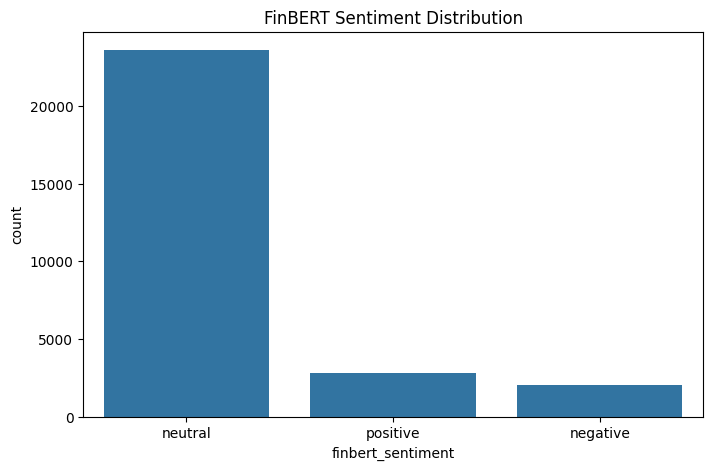

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='finbert_sentiment',
    data=df
)

plt.title(
    'FinBERT Sentiment Distribution'
)

plt.show()

Load RoBERTa

In [ ]:
roberta = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest"
)

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

STEP 23 — Run RoBERTa

In [ ]:
roberta_results = roberta(
    texts,
    batch_size=32
)

In [ ]:
roberta_results[:10]

[{'label': 'neutral', 'score': 0.8827228546142578},
 {'label': 'neutral', 'score': 0.6169093251228333},
 {'label': 'negative', 'score': 0.5491296052932739},
 {'label': 'neutral', 'score': 0.7240571975708008},
 {'label': 'neutral', 'score': 0.8083007335662842},
 {'label': 'neutral', 'score': 0.6719414591789246},
 {'label': 'positive', 'score': 0.855464518070221},
 {'label': 'neutral', 'score': 0.8888241052627563},
 {'label': 'neutral', 'score': 0.8660592436790466},
 {'label': 'neutral', 'score': 0.8641660213470459}]

In [ ]:
[
 {'label': 'positive', 'score': 0.94},
 {'label': 'neutral', 'score': 0.81},
 {'label': 'negative', 'score': 0.88}
]

[{'label': 'positive', 'score': 0.94},
 {'label': 'neutral', 'score': 0.81},
 {'label': 'negative', 'score': 0.88}]

STEP 24 — Sentiment columns

In [ ]:
df['roberta_sentiment'] = [
    x['label']
    for x in roberta_results
]

In [ ]:
df['roberta_score'] = [
    x['score']
    for x in roberta_results
]

In [ ]:
df['roberta_sentiment'].value_counts()

,count
roberta_sentiment,
neutral,24526
positive,2328
negative,1576


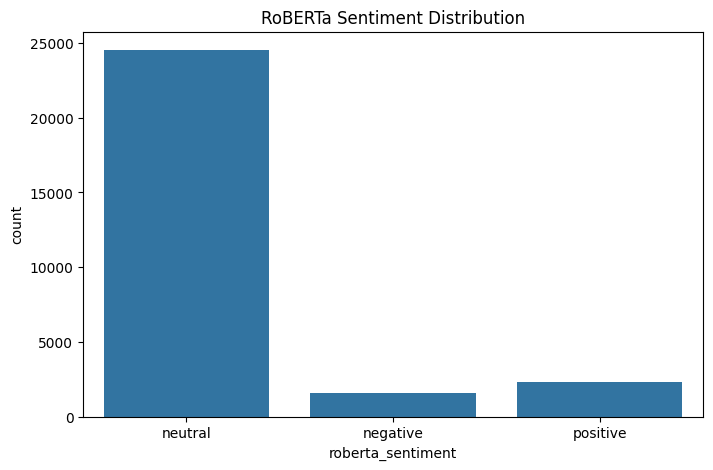

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='roberta_sentiment',
    data=df
)

plt.title(
    'RoBERTa Sentiment Distribution'
)

plt.show()

STEP 27 — Load VADER

In [ ]:
from nltk.sentiment.vader import (
    SentimentIntensityAnalyzer
)

In [ ]:
sia = SentimentIntensityAnalyzer()

STEP 28 — Create VADER Function

In [ ]:
def vader_sentiment(text):

    score = (
        sia.polarity_scores(text)
        ['compound']
    )

    if score >= 0.05:
        return 'positive'

    elif score <= -0.05:
        return 'negative'

    else:
        return 'neutral'

STEP 29 — Apply VADER

In [ ]:
df['vader_sentiment'] = (
    df['processed_text']
    .apply(vader_sentiment)
)

STEP 30 — VADER Distribution

In [ ]:
df['vader_sentiment'].value_counts()

,count
vader_sentiment,
neutral,14341
positive,11020
negative,3069


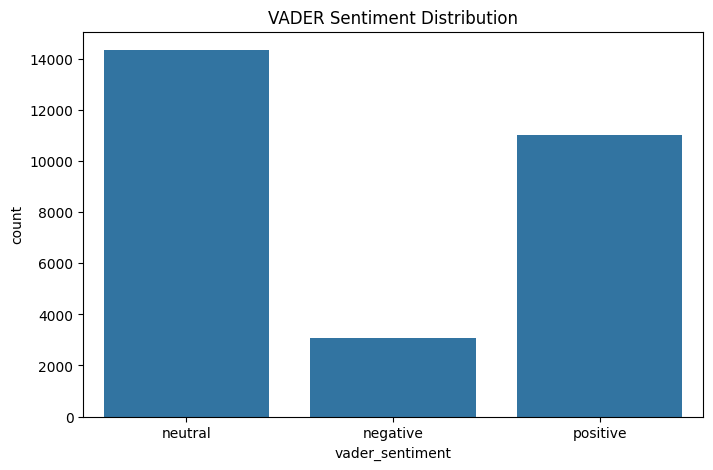

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='vader_sentiment',
    data=df
)

plt.title(
    'VADER Sentiment Distribution'
)

plt.show()

FinancialBERT

In [ ]:
from transformers import pipeline

In [ ]:
financialbert = pipeline(
"sentiment-analysis",
model="ahmedrachid/FinancialBERT-Sentiment-Analysis"
)

config.json:   0%|          | 0.00/789 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/439M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/369 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/439M [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/226k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/464k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
texts = df['processed_text'].tolist()

STEP 37 — Run FinancialBERT

In [ ]:
financialbert_results = financialbert(
    texts,
    batch_size=32
)

Prepare_text

In [ ]:
texts = df['processed_text'].tolist()

In [ ]:
[
 {'label': 'positive', 'score': 0.97},
 {'label': 'neutral', 'score': 0.88},
 {'label': 'negative', 'score': 0.93}
]

[{'label': 'positive', 'score': 0.97},
 {'label': 'neutral', 'score': 0.88},
 {'label': 'negative', 'score': 0.93}]

STEP 38 — Check Output Format FIRST

In [ ]:
financialbert_results[:10]

[{'label': 'neutral', 'score': 0.9995970129966736},
 {'label': 'neutral', 'score': 0.9956112504005432},
 {'label': 'neutral', 'score': 0.9946130514144897},
 {'label': 'positive', 'score': 0.9893984794616699},
 {'label': 'neutral', 'score': 0.9986242055892944},
 {'label': 'neutral', 'score': 0.9995001554489136},
 {'label': 'neutral', 'score': 0.9996101260185242},
 {'label': 'neutral', 'score': 0.9996905326843262},
 {'label': 'neutral', 'score': 0.9996856451034546},
 {'label': 'neutral', 'score': 0.9996497631072998}]

Save FinancialBERT Results

In [ ]:
df['financialbert_sentiment'] = [

    x['label']

    for x in financialbert_results
]

In [ ]:
df['financialbert_score'] = [

    x['score']

    for x in financialbert_results
]

STEP 40 — Check Results

In [ ]:
df[
[
'processed_text',
'financialbert_sentiment',
'financialbert_score'
]
].head(10)

,processed_text,financialbert_sentiment,financialbert_score
0,video office minding business david solomon te...,neutral,0.999597
1,price lumber lbf since hitting ytd highs macys...,neutral,0.995611
2,says american dream dead,neutral,0.994613
3,barry silbert extremely optimistic bitcoin pre...,positive,0.989398
4,satellites avoid attacks space junk circling e...,neutral,0.998624
5,david butlers favorite fang stock isnt realmon...,neutral,0.999500
6,dont miss convo one favorite thinkers,neutral,0.999610
7,us intelligence documents nelson mandela made ...,neutral,0.999691
8,senate wants emergency alerts go netflix spoti...,neutral,0.999686
9,hedge fund manager marc larsy says bitcoin k p...,neutral,0.999650


STEP 41 — Check Sentiment Distribution

In [ ]:
df[
'financialbert_sentiment'
].value_counts()

,count
financialbert_sentiment,
neutral,21696
positive,5003
negative,1731


STEP 42 — Create Graph

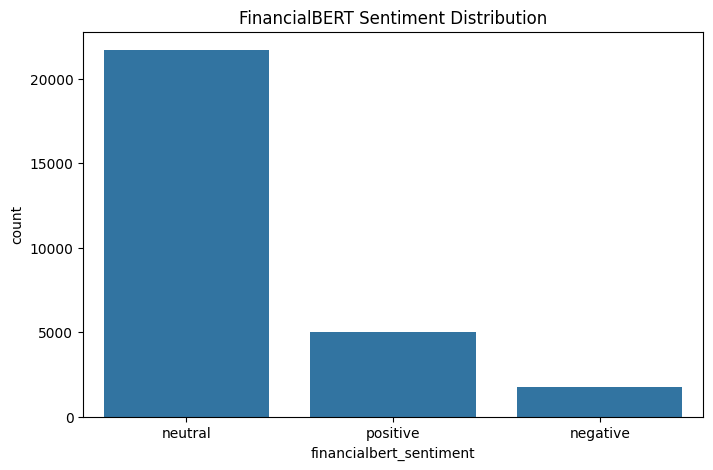

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='financialbert_sentiment',
    data=df
)

plt.title(
'FinancialBERT Sentiment Distribution'
)

plt.show()

In [ ]:
df.columns

Index(['text', 'original_text', 'clean_text', 'processed_text',
       'finbert_sentiment', 'finbert_score', 'roberta_sentiment',
       'roberta_score', 'vader_sentiment', 'financialbert_sentiment',
       'financialbert_score'],
      dtype='object')

STEP 31 — Compare All Models
We compare:

FinBERT
RoBERTa
VADER
FinancialBERT

In [ ]:
comparison = pd.DataFrame({

'FinBERT':
df['finbert_sentiment']
.value_counts(),

'RoBERTa':
df['roberta_sentiment']
.value_counts(),

'VADER':
df['vader_sentiment']
.value_counts(),

'FinancialBERT':
df['financialbert_sentiment']
.value_counts()

})

comparison

,FinBERT,RoBERTa,VADER,FinancialBERT
neutral,23604,24526,14341,21696
positive,2780,2328,11020,5003
negative,2046,1576,3069,1731


STEP 44 — Comparison Graph

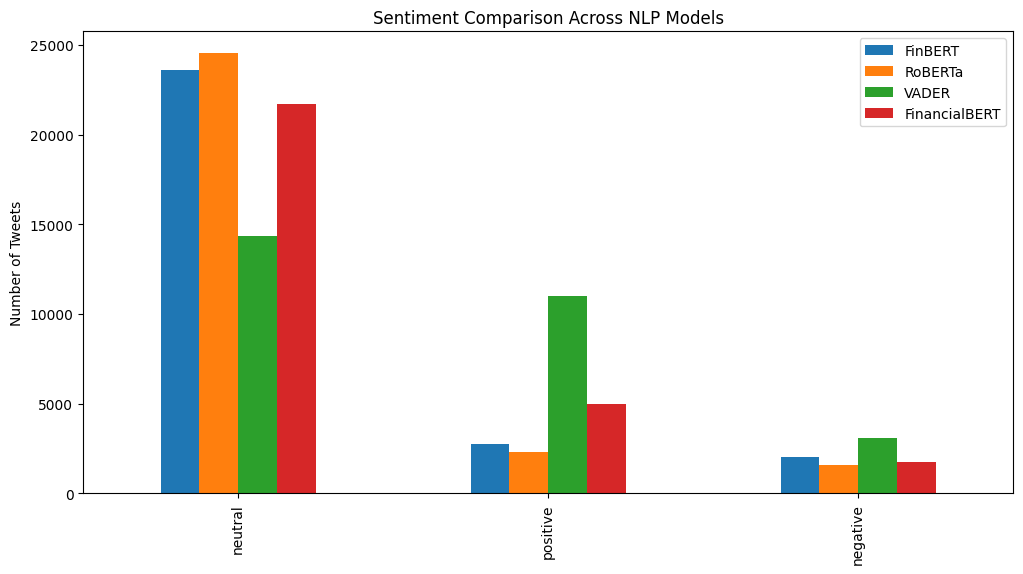

In [ ]:
comparison.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title(
'Sentiment Comparison Across NLP Models'
)

plt.ylabel(
'Number of Tweets'
)

plt.show()

In [ ]:
comparison_percentage = (
    comparison.div(comparison.sum(axis=0), axis=1)
    * 100
)

comparison_percentage.round(2)

,FinBERT,RoBERTa,VADER,FinancialBERT
neutral,83.02,86.27,50.44,76.31
positive,9.78,8.19,38.76,17.60
negative,7.20,5.54,10.79,6.09


STEP 45 — Create Comparison Table

In [ ]:
comparison = pd.DataFrame({

'FinBERT':
df['finbert_sentiment']
.value_counts(),

'RoBERTa':
df['roberta_sentiment']
.value_counts(),

'VADER':
df['vader_sentiment']
.value_counts(),

'FinancialBERT':
df['financialbert_sentiment']
.value_counts()

})

comparison

,FinBERT,RoBERTa,VADER,FinancialBERT
neutral,23604,24526,14341,21696
positive,2780,2328,11020,5003
negative,2046,1576,3069,1731


STEP 46 — Convert to Percentages

In [ ]:
comparison_percentage = (

comparison.div(
comparison.sum(axis=0),
axis=1

) * 100

)

In [ ]:
comparison_percentage.round(2)

,FinBERT,RoBERTa,VADER,FinancialBERT
neutral,83.02,86.27,50.44,76.31
positive,9.78,8.19,38.76,17.60
negative,7.20,5.54,10.79,6.09


STEP 47

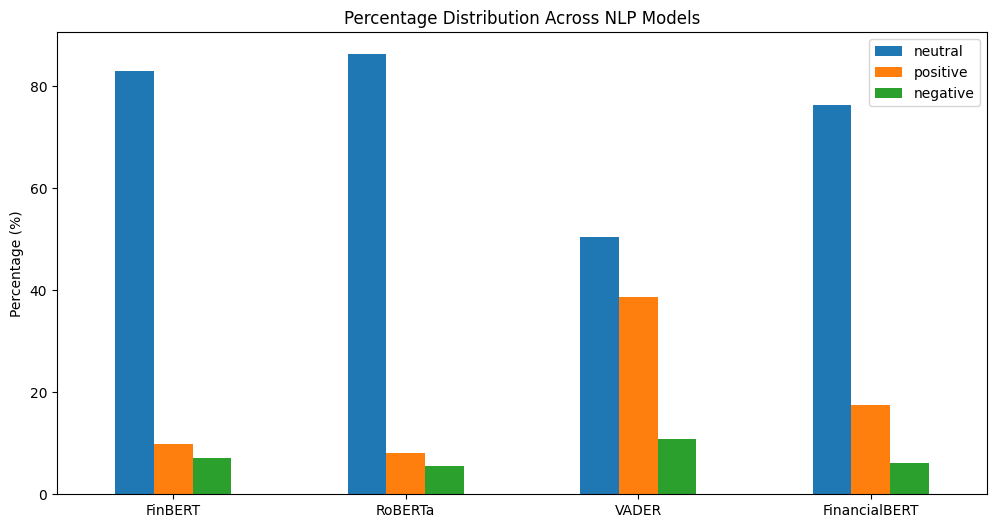

In [ ]:
comparison_percentage.T.plot(

kind='bar',
figsize=(12,6)

)

plt.title(
'Percentage Distribution Across NLP Models'
)

plt.ylabel(
'Percentage (%)'
)

plt.xticks(rotation=0)

plt.show()

STEP 48 — Find Model Disagreement

In [ ]:
finbert_roberta_disagreement = df[

df['finbert_sentiment']

!=

df['roberta_sentiment']

]

In [ ]:
len(finbert_roberta_disagreement)

5831

View examples

In [ ]:
finbert_roberta_disagreement[
[
'original_text',
'processed_text',
'finbert_sentiment',
'roberta_sentiment'
]
].head(20)

,original_text,processed_text,finbert_sentiment,roberta_sentiment
1,The price of lumber $LB_F is down 22% since hi...,price lumber lbf since hitting ytd highs macys...,positive,neutral
2,Who says the American Dream is dead? https://t...,says american dream dead,neutral,negative
3,Barry Silbert is extremely optimistic on bitco...,barry silbert extremely optimistic bitcoin pre...,positive,neutral
6,Don’t miss my convo with one of my favorite th...,dont miss convo one favorite thinkers,neutral,positive
12,Bond traders are ahead of Jerome Powell when i...,bond traders ahead jerome powell comes inflati...,negative,neutral
15,The gap tightens in the race to a trillion dol...,gap tightens race trillion dollar valuation am...,positive,neutral
19,Only two northern white rhinos still exist mak...,two northern white rhinos still exist making w...,neutral,negative
23,EBay revenue misses as weak U.S. sporting seas...,ebay revenue misses weak us sporting season hi...,negative,neutral
30,$INFO $C Asia Stocks Signal Gains; Dollar Weak...,info c asia stocks signal gains dollar weaknes...,negative,neutral
31,RT @dailypoliticaln: Fluor Co. $NEW $FLR Stock...,rt fluor co new flr stock rating upgraded zack...,positive,neutral


STEP 49 — Compare FinBERT vs VADER

In [ ]:
finbert_vader_disagreement = df[

df['finbert_sentiment']

!=

df['vader_sentiment']

]

In [ ]:
len(finbert_vader_disagreement)

13312

In [ ]:
finbert_vader_disagreement[
[
'original_text',
'processed_text',
'finbert_sentiment',
'vader_sentiment'
]
].head(20)

,original_text,processed_text,finbert_sentiment,vader_sentiment
1,The price of lumber $LB_F is down 22% since hi...,price lumber lbf since hitting ytd highs macys...,positive,neutral
2,Who says the American Dream is dead? https://t...,says american dream dead,neutral,negative
4,How satellites avoid attacks and space junk wh...,satellites avoid attacks space junk circling e...,neutral,negative
5,.@RealMoney's David Butler's favorite FANG sto...,david butlers favorite fang stock isnt realmon...,neutral,positive
6,Don’t miss my convo with one of my favorite th...,dont miss convo one favorite thinkers,neutral,positive
7,U.S. intelligence documents on Nelson Mandela ...,us intelligence documents nelson mandela made ...,neutral,positive
8,Senate wants emergency alerts to go out throug...,senate wants emergency alerts go netflix spoti...,neutral,negative
10,U.S. proposes expedited appeal in fight with A...,us proposes expedited appeal fight atampt time...,neutral,negative
12,Bond traders are ahead of Jerome Powell when i...,bond traders ahead jerome powell comes inflati...,negative,neutral
13,Alcoa cuts adjusted EBITDA forecast citing tar...,alcoa cuts adjusted ebitda forecast citing tar...,negative,neutral


STEP 50 — Compare FinBERT vs FinancialBERT

In [ ]:
finbert_financialbert_disagreement = df[

df['finbert_sentiment']

!=

df['financialbert_sentiment']

]

In [ ]:
len(finbert_financialbert_disagreement)

6604

In [ ]:
finbert_financialbert_disagreement[
[
'original_text',
'processed_text',
'finbert_sentiment',
'financialbert_sentiment'
]
].head(20)

,original_text,processed_text,finbert_sentiment,financialbert_sentiment
1,The price of lumber $LB_F is down 22% since hi...,price lumber lbf since hitting ytd highs macys...,positive,neutral
10,U.S. proposes expedited appeal in fight with A...,us proposes expedited appeal fight atampt time...,neutral,positive
12,Bond traders are ahead of Jerome Powell when i...,bond traders ahead jerome powell comes inflati...,negative,neutral
14,Customers urge boycott of MGM Resorts after th...,customers urge boycott mgm resorts casino file...,negative,neutral
15,The gap tightens in the race to a trillion dol...,gap tightens race trillion dollar valuation am...,positive,neutral
19,Only two northern white rhinos still exist mak...,two northern white rhinos still exist making w...,neutral,negative
22,Charts say #RealMoneySOD $GOOGL could rise 17%...,charts say realmoneysod googl could rise,neutral,positive
27,The robot homie R2-D2 told me to buy sell and ...,robot homie rd told buy sell hold fidelity nat...,neutral,positive
30,$INFO $C Asia Stocks Signal Gains; Dollar Weak...,info c asia stocks signal gains dollar weaknes...,negative,positive
44,Analysts Expect Mosaic Co $MOS Will Announce E...,analysts expect mosaic co mos announce earning...,positive,neutral


STEP 51 — Calculate Agreement Rate

In [ ]:
agreement = (

df['finbert_sentiment']

==

df['roberta_sentiment']

).mean() * 100

In [ ]:
print(
f"Agreement Rate: {agreement:.2f}%"
)

Agreement Rate: 79.49%


FinBERT vs VADER

In [ ]:
agreement_vader = (

df['finbert_sentiment']

==

df['vader_sentiment']

).mean() * 100

print(
f"Agreement Rate: {agreement_vader:.2f}%"
)

Agreement Rate: 53.18%


FinBERT vs FinancialBERT

In [ ]:
agreement_financialbert = (

df['finbert_sentiment']

==

df['financialbert_sentiment']

).mean() * 100

print(
f"Agreement Rate: {agreement_financialbert:.2f}%"
)

Agreement Rate: 76.77%


Evaluation

STEP 52 — Create Ground Truth Labels

In [ ]:
evaluation_df = df.sample(
    300,
    random_state=42
).copy()

In [ ]:
evaluation_df = evaluation_df[
[
'original_text',
'finbert_sentiment',
'roberta_sentiment',
'vader_sentiment',
'financialbert_sentiment'
]
]

In [ ]:
evaluation_df.reset_index(
    drop=True,
    inplace=True
)

In [ ]:
evaluation_df.head(20)

,original_text,finbert_sentiment,roberta_sentiment,vader_sentiment,financialbert_sentiment
0,Barnes &amp; Noble Education $BNED versus Hibb...,neutral,neutral,positive,neutral
1,Seagate BarraCuda SSD Review @Seagate @_adam_a...,neutral,neutral,neutral,neutral
2,RT @420_invest: 🍁@420_invest🍁 We fund #mariju...,neutral,neutral,positive,neutral
3,Assurant $AIZ Coverage Initiated at Keefe Bruy...,neutral,neutral,neutral,neutral
4,Motorola Solutions $MSI Downgraded by Zacks In...,negative,negative,positive,neutral
5,Douglas Emmett $DEI &amp; Mid-America Apartmen...,neutral,neutral,negative,neutral
6,$INFO new insider selling: 100 shares. https:/...,neutral,neutral,positive,neutral
7,$HCA open interest for maturity 07/13/2018. Hi...,neutral,neutral,positive,neutral
8,$CME Max Pain=165.00. Maturity=07/20/2018. #ma...,neutral,neutral,negative,neutral
9,Platform Specialty Products $PAH Rating Increa...,positive,neutral,positive,positive


STEP 53 — Add Manual Label Column

In [ ]:
evaluation_df[
'true_label'
] = ''

STEP 54 — Export for Manual Labeling

In [ ]:
evaluation_df.to_csv(
    "manual_labeling_1.csv",
    index=False
)

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/sample_data/thesis_after_comments.csv')

In [ ]:
evaluation_df =  pd.read_csv('/content/sample_data/thesis_after_comments.csv')

STEP 58 — Check Labels

In [ ]:
evaluation_df.head(50)

,original_text,finbert_sentiment,roberta_sentiment,vader_sentiment,financialbert_sentiment,true_label
0,Barnes &amp; Noble Education $BNED versus Hibb...,neutral,neutral,positive,neutral,neutral
1,Seagate BarraCuda SSD Review @Seagate @_adam_a...,neutral,neutral,neutral,neutral,neutral
2,RT @420_invest: 🍁@420_invest🍁 We fund #mariju...,neutral,neutral,positive,neutral,neutral
3,Assurant $AIZ Coverage Initiated at Keefe Bruy...,neutral,neutral,neutral,neutral,neutral
4,Motorola Solutions $MSI Downgraded by Zacks In...,negative,negative,positive,neutral,negative
5,Douglas Emmett $DEI &amp; Mid-America Apartmen...,neutral,neutral,negative,neutral,neutral
6,$INFO new insider selling: 100 shares. https:/...,neutral,neutral,positive,neutral,neutral
7,$HCA open interest for maturity 07/13/2018. Hi...,neutral,neutral,positive,neutral,neutral
8,$CME Max Pain=165.00. Maturity=07/20/2018. #ma...,neutral,neutral,negative,neutral,neutral
9,Platform Specialty Products $PAH Rating Increa...,positive,neutral,positive,positive,positive


In [ ]:
evaluation_df['true_label'].value_counts()

,count
true_label,
neutral,187
positive,68
negative,45


In [ ]:
evaluation_df[['original_text','true_label']].head(20)

,original_text,true_label
0,Barnes &amp; Noble Education $BNED versus Hibb...,neutral
1,Seagate BarraCuda SSD Review @Seagate @_adam_a...,neutral
2,RT @420_invest: 🍁@420_invest🍁 We fund #mariju...,neutral
3,Assurant $AIZ Coverage Initiated at Keefe Bruy...,neutral
4,Motorola Solutions $MSI Downgraded by Zacks In...,negative
5,Douglas Emmett $DEI &amp; Mid-America Apartmen...,neutral
6,$INFO new insider selling: 100 shares. https:/...,neutral
7,$HCA open interest for maturity 07/13/2018. Hi...,neutral
8,$CME Max Pain=165.00. Maturity=07/20/2018. #ma...,neutral
9,Platform Specialty Products $PAH Rating Increa...,positive


STEP 57 — Import Evaluation Libraries

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

Evaluate All Models Together

In [ ]:
results = []

models = {

    'FinBERT': evaluation_df['finbert_sentiment'],

    'RoBERTa': evaluation_df['roberta_sentiment'],

    'VADER': evaluation_df['vader_sentiment'],

    'FinancialBERT': evaluation_df['financialbert_sentiment']

}

for model_name, prediction in models.items():

    accuracy = accuracy_score(
        evaluation_df['true_label'],
        prediction
    )

    precision = precision_score(
        evaluation_df['true_label'],
        prediction,
        average='weighted'
    )

    recall = recall_score(
        evaluation_df['true_label'],
        prediction,
        average='weighted'
    )

    f1 = f1_score(
        evaluation_df['true_label'],
        prediction,
        average='weighted'
    )

    results.append([
        model_name,
        accuracy,
        precision,
        recall,
        f1
    ])

Create Results Table

In [ ]:
results_df = pd.DataFrame(

results,

columns=[
    'Model',
    'Accuracy',
    'Precision',
    'Recall',
    'F1 Score'
]

)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,FinBERT,0.770000,0.783760,0.770000,0.743068
1,RoBERTa,0.693333,0.697402,0.693333,0.653247
2,VADER,0.560000,0.654547,0.560000,0.582046
3,FinancialBERT,0.816667,0.828671,0.816667,0.805509


Performance Graph

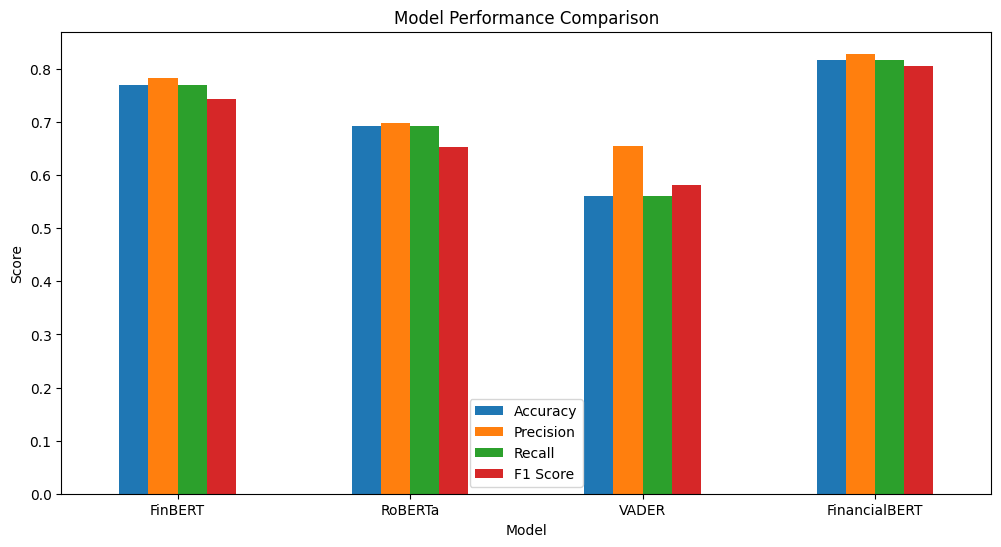

In [ ]:
results_df.set_index(
    'Model'
).plot(
    kind='bar',
    figsize=(12,6)
)

plt.title(
    'Model Performance Comparison'
)

plt.ylabel(
    'Score'
)

plt.xticks(rotation=0)

plt.show()

Confusion Matrix for FinBERT

In [ ]:
cm_finbert = confusion_matrix(

    evaluation_df['true_label'],

    evaluation_df['finbert_sentiment'],

    labels=[
        'negative',
        'neutral',
        'positive'
    ]

)

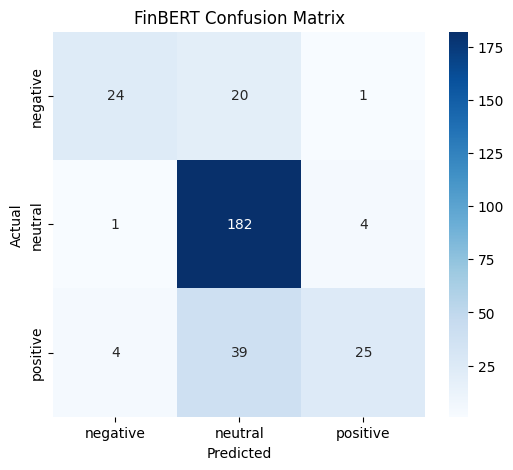

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(

    cm_finbert,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=[
        'negative',
        'neutral',
        'positive'
    ],

    yticklabels=[
        'negative',
        'neutral',
        'positive'
    ]

)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('FinBERT Confusion Matrix')

plt.show()

In [ ]:
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,FinBERT,0.770000,0.783760,0.770000,0.743068
1,RoBERTa,0.693333,0.697402,0.693333,0.653247
2,VADER,0.560000,0.654547,0.560000,0.582046
3,FinancialBERT,0.816667,0.828671,0.816667,0.805509


Model Performance Comparison

<Figure size 1000x600 with 0 Axes>

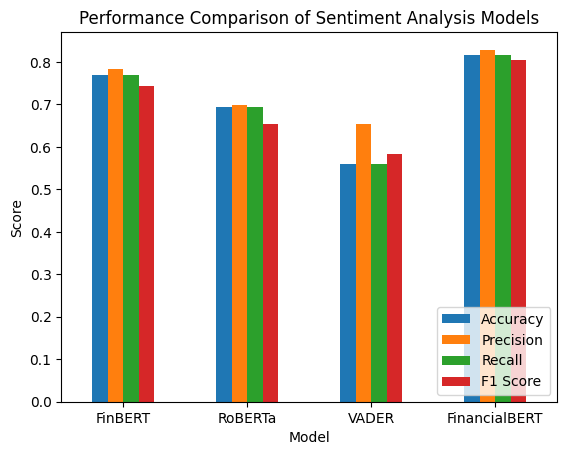

In [ ]:
plt.figure(figsize=(10,6))

results_df.set_index('Model').plot(
    kind='bar'
)

plt.title(
    'Performance Comparison of Sentiment Analysis Models'
)

plt.ylabel('Score')

plt.xticks(rotation=0)

plt.legend(
    loc='lower right'
)

plt.show()

Accuracy Comparison

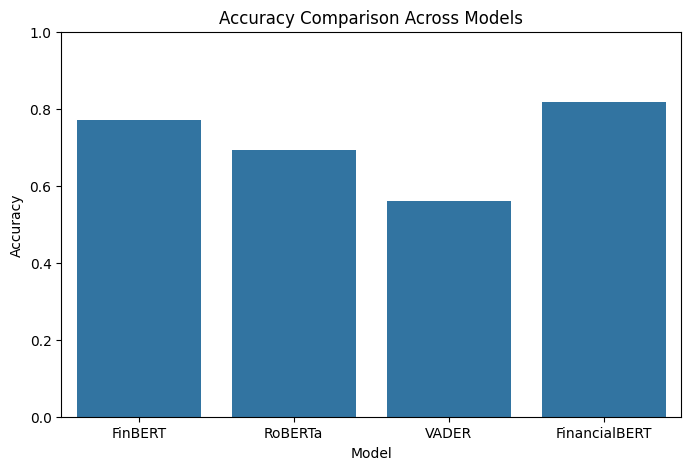

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=results_df
)

plt.title(
    'Accuracy Comparison Across Models'
)

plt.ylim(0,1)

plt.show()

F1 Score Comparison

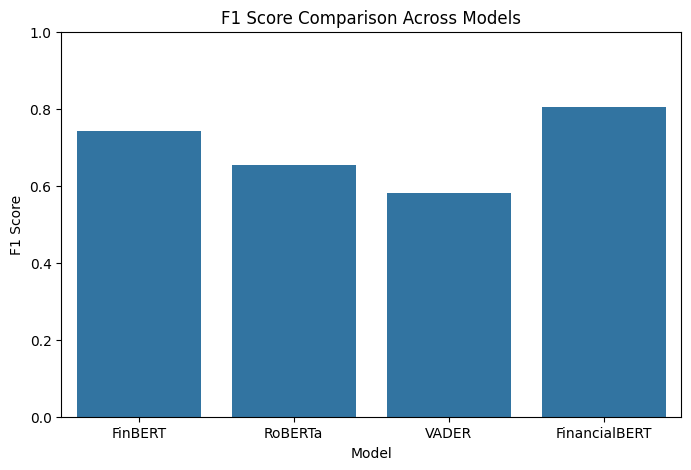

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='F1 Score',
    data=results_df
)

plt.title(
    'F1 Score Comparison Across Models'
)

plt.ylim(0,1)

plt.show()

Confusion Matrix for Every Model

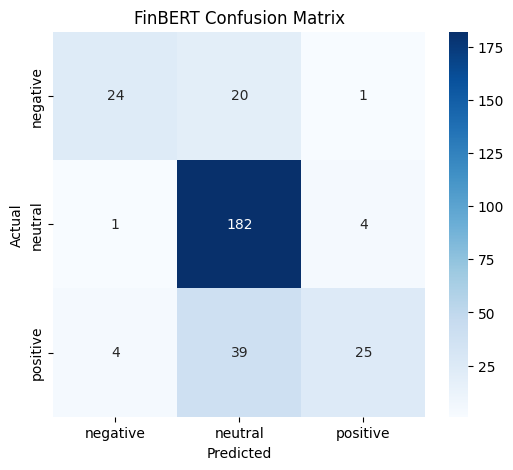

In [ ]:
cm = confusion_matrix(
    evaluation_df['true_label'],
    evaluation_df['finbert_sentiment'],
    labels=['negative','neutral','positive']
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['negative','neutral','positive'],
    yticklabels=['negative','neutral','positive']
)

plt.title('FinBERT Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

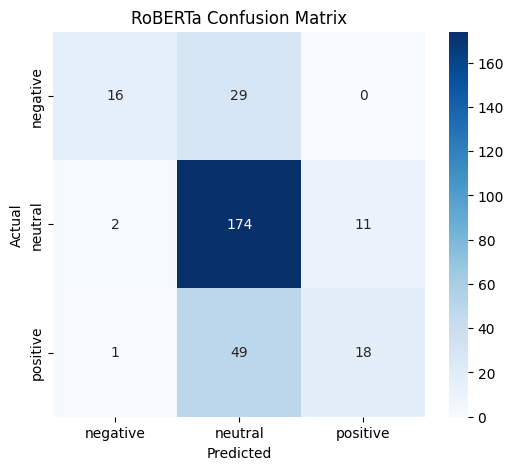

In [ ]:
cm = confusion_matrix(
    evaluation_df['true_label'],
    evaluation_df['roberta_sentiment'],
    labels=['negative','neutral','positive']
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['negative','neutral','positive'],
    yticklabels=['negative','neutral','positive']
)

plt.title('RoBERTa Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

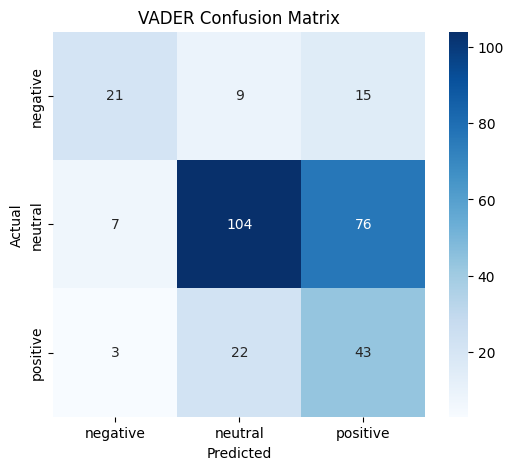

In [ ]:
cm = confusion_matrix(
    evaluation_df['true_label'],
    evaluation_df['vader_sentiment'],
    labels=['negative','neutral','positive']
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['negative','neutral','positive'],
    yticklabels=['negative','neutral','positive']
)

plt.title('VADER Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

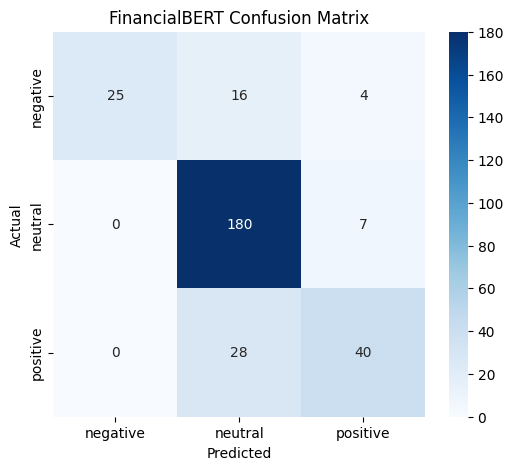

In [ ]:
cm = confusion_matrix(
    evaluation_df['true_label'],
    evaluation_df['financialbert_sentiment'],
    labels=['negative','neutral','positive']
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['negative','neutral','positive'],
    yticklabels=['negative','neutral','positive']
)

plt.title('FinancialBERT Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

Combined confusion matrix

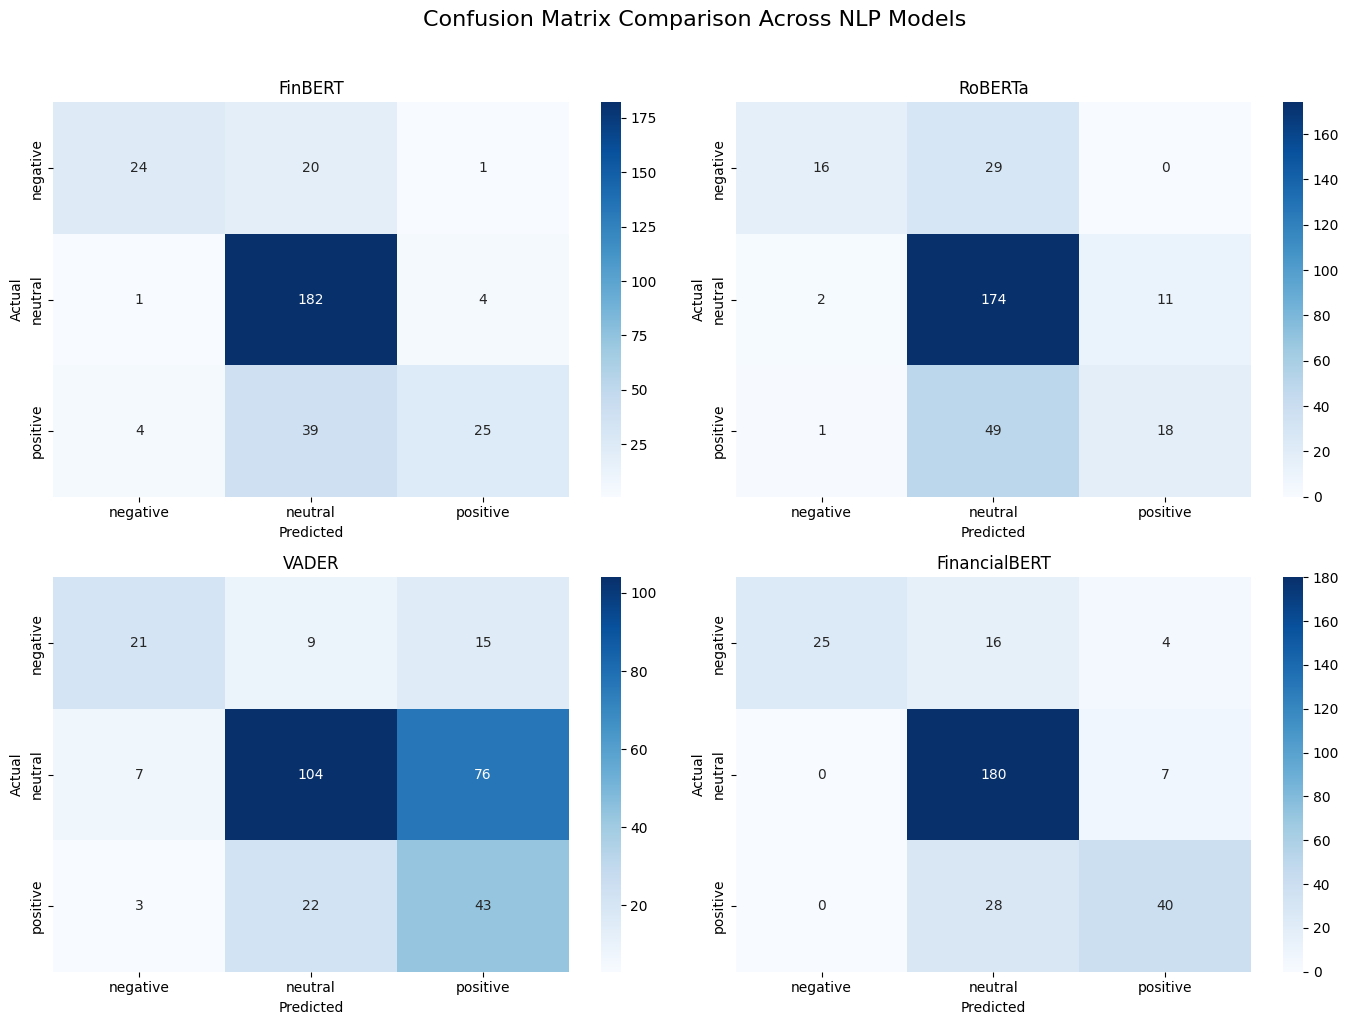

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

models = {
    'FinBERT': 'finbert_sentiment',
    'RoBERTa': 'roberta_sentiment',
    'VADER': 'vader_sentiment',
    'FinancialBERT': 'financialbert_sentiment'
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes = axes.flatten()

for ax, (model_name, column) in zip(axes, models.items()):

    cm = confusion_matrix(
        evaluation_df['true_label'],
        evaluation_df[column],
        labels=['negative', 'neutral', 'positive']
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['negative', 'neutral', 'positive'],
        yticklabels=['negative', 'neutral', 'positive'],
        ax=ax
    )

    ax.set_title(f'{model_name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle(
    'Confusion Matrix Comparison Across NLP Models',
    fontsize=16,
    y=1.02
)

plt.tight_layout()

plt.show()

Agreement Rate Comparison

In [ ]:
agreement_results = pd.DataFrame({

'Comparison':[
'FinBERT vs RoBERTa',
'FinBERT vs VADER',
'FinBERT vs FinancialBERT'
],

'Agreement Rate':[
81.07,
56.95,
74.16
]

})

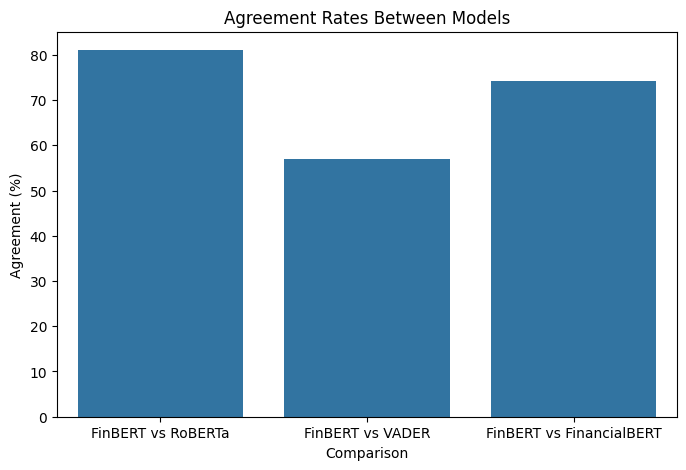

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Comparison',
    y='Agreement Rate',
    data=agreement_results
)

plt.title(
    'Agreement Rates Between Models'
)

plt.ylabel('Agreement (%)')

plt.show()

classification report

FinancialBERT (Best Model)

In [ ]:
from sklearn.metrics import classification_report

print("FinancialBERT Classification Report\n")

print(
    classification_report(
        evaluation_df['true_label'],
        evaluation_df['financialbert_sentiment']
    )
)

FinancialBERT Classification Report

              precision    recall  f1-score   support

    negative       1.00      0.56      0.71        45
     neutral       0.80      0.96      0.88       187
    positive       0.78      0.59      0.67        68

    accuracy                           0.82       300
   macro avg       0.86      0.70      0.75       300
weighted avg       0.83      0.82      0.81       300



FinBERT

In [ ]:
print("FinBERT Classification Report\n")

print(
    classification_report(
        evaluation_df['true_label'],
        evaluation_df['finbert_sentiment']
    )
)

FinBERT Classification Report

              precision    recall  f1-score   support

    negative       0.83      0.53      0.65        45
     neutral       0.76      0.97      0.85       187
    positive       0.83      0.37      0.51        68

    accuracy                           0.77       300
   macro avg       0.81      0.62      0.67       300
weighted avg       0.78      0.77      0.74       300




RoBERTa

In [ ]:
print("RoBERTa Classification Report\n")

print(
    classification_report(
        evaluation_df['true_label'],
        evaluation_df['roberta_sentiment']
    )
)

RoBERTa Classification Report

              precision    recall  f1-score   support

    negative       0.84      0.36      0.50        45
     neutral       0.69      0.93      0.79       187
    positive       0.62      0.26      0.37        68

    accuracy                           0.69       300
   macro avg       0.72      0.52      0.55       300
weighted avg       0.70      0.69      0.65       300



VADER

In [ ]:
print("VADER Classification Report\n")

print(
    classification_report(
        evaluation_df['true_label'],
        evaluation_df['vader_sentiment']
    )
)

VADER Classification Report

              precision    recall  f1-score   support

    negative       0.68      0.47      0.55        45
     neutral       0.77      0.56      0.65       187
    positive       0.32      0.63      0.43        68

    accuracy                           0.56       300
   macro avg       0.59      0.55      0.54       300
weighted avg       0.65      0.56      0.58       300



Generate All Classification Reports Together

In [ ]:
models = {
    'FinBERT': 'finbert_sentiment',
    'RoBERTa': 'roberta_sentiment',
    'VADER': 'vader_sentiment',
    'FinancialBERT': 'financialbert_sentiment'
}

for model_name, column in models.items():

    print("\n" + "="*60)
    print(model_name)
    print("="*60)

    print(
        classification_report(
            evaluation_df['true_label'],
            evaluation_df[column]
        )
    )


FinBERT
              precision    recall  f1-score   support

    negative       0.83      0.53      0.65        45
     neutral       0.76      0.97      0.85       187
    positive       0.83      0.37      0.51        68

    accuracy                           0.77       300
   macro avg       0.81      0.62      0.67       300
weighted avg       0.78      0.77      0.74       300


RoBERTa
              precision    recall  f1-score   support

    negative       0.84      0.36      0.50        45
     neutral       0.69      0.93      0.79       187
    positive       0.62      0.26      0.37        68

    accuracy                           0.69       300
   macro avg       0.72      0.52      0.55       300
weighted avg       0.70      0.69      0.65       300


VADER
              precision    recall  f1-score   support

    negative       0.68      0.47      0.55        45
     neutral       0.77      0.56      0.65       187
    positive       0.32      0.63      0.43       

| Model         | Accuracy | Precision | Recall | F1 Score |
| ------------- | -------: | --------: | -----: | -------: |
| FinancialBERT |    81.67 |     82.87 |  81.67 |    80.55 |
| FinBERT       |    77.00 |     78.38 |  77.00 |    74.31 |
| RoBERTa       |    69.33 |     69.74 |  69.33 |    65.32 |
| VADER         |    56.00 |     65.45 |  56.00 |    58.20 |


Phase 7  - Visualizations

Figure 1 — Sentiment Distribution Comparison  -- already did

Figure 2 — Agreement Rate Comparison - already did
Shows model consistency.

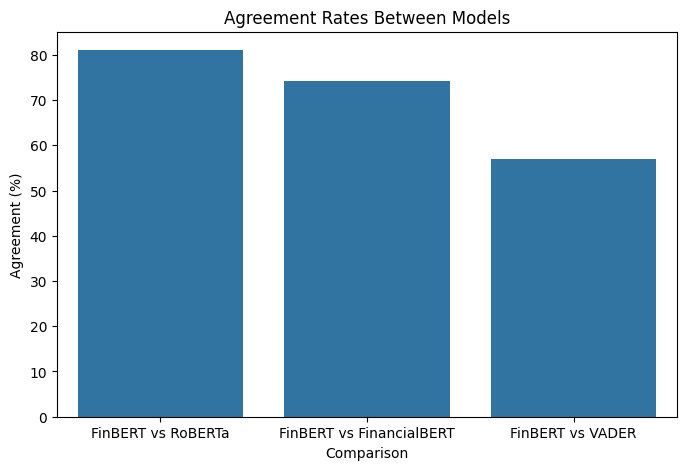

In [ ]:
agreement_results = pd.DataFrame({

'Comparison':[
'FinBERT vs RoBERTa',
'FinBERT vs FinancialBERT',
'FinBERT vs VADER'
],

'Agreement Rate':[
81.07,
74.16,
56.95
]

})

plt.figure(figsize=(8,5))

sns.barplot(
    x='Comparison',
    y='Agreement Rate',
    data=agreement_results
)

plt.title(
    'Agreement Rates Between Models'
)

plt.ylabel('Agreement (%)')

plt.show()

Figure 3 — Accuracy Comparison

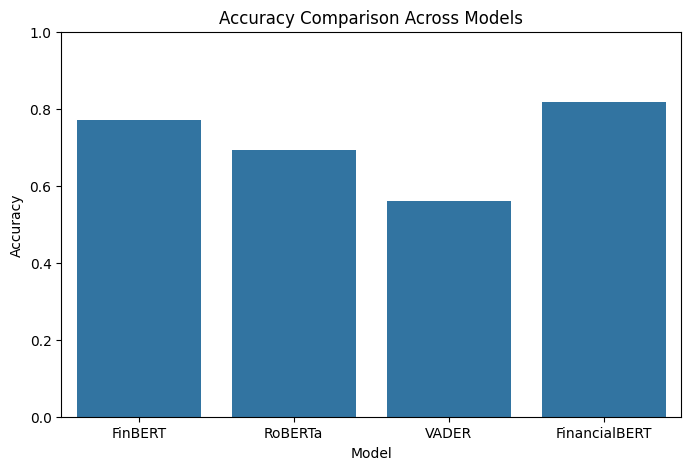

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=results_df
)

plt.title(
    'Accuracy Comparison Across Models'
)

plt.ylim(0,1)

plt.show()

Figure 4 — F1 Score Comparison

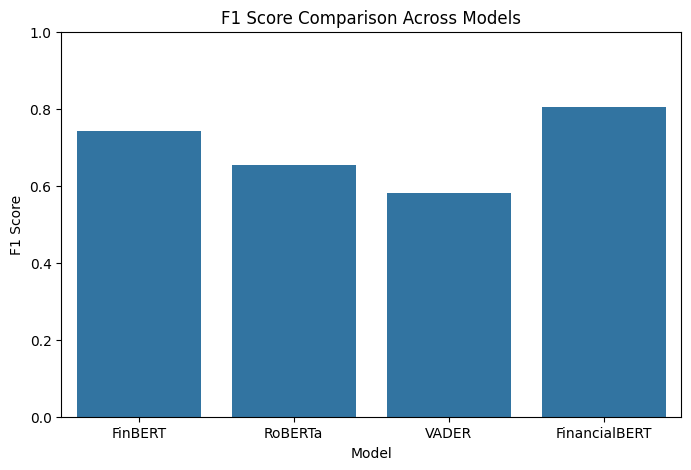

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='F1 Score',
    data=results_df
)

plt.title(
    'F1 Score Comparison Across Models'
)

plt.ylim(0,1)

plt.show()

Figure 5 — Combined Confusion Matrix  - already did

Figure 6 — Performance Comparison Dashboard

<Figure size 1200x600 with 0 Axes>

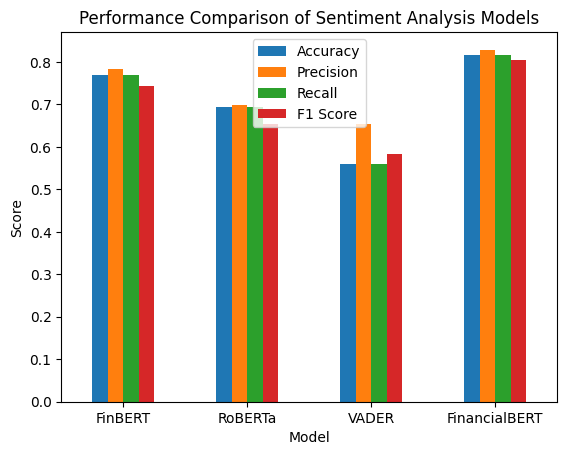

In [ ]:
plt.figure(figsize=(12,6))

results_df.set_index('Model').plot(
    kind='bar'
)

plt.title(
    'Performance Comparison of Sentiment Analysis Models'
)

plt.ylabel('Score')

plt.xticks(rotation=0)

plt.show()

Figure 7 — Model Ranking

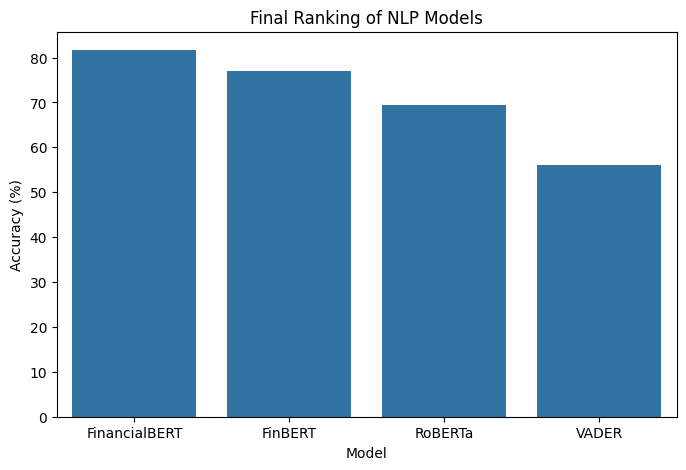

In [ ]:
ranking_df = pd.DataFrame({

'Model':[
'FinancialBERT',
'FinBERT',
'RoBERTa',
'VADER'
],

'Accuracy':[
81.67,
77.00,
69.33,
56.00
]

})

plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=ranking_df
)

plt.title(
    'Final Ranking of NLP Models'
)

plt.ylabel('Accuracy (%)')

plt.show()

 Results Table

In [ ]:
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,FinBERT,0.770000,0.783760,0.770000,0.743068
1,RoBERTa,0.693333,0.697402,0.693333,0.653247
2,VADER,0.560000,0.654547,0.560000,0.582046
3,FinancialBERT,0.816667,0.828671,0.816667,0.805509


In [ ]:
results_df.to_csv(
    'final_results.csv',
    index=False
)